In [199]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder

In [200]:
df=pd.read_csv('data.csv')
df.head()

,age,income,gender,city_tier,education_level,marital_status,occupation,monthly_usage_hours,num_logins,avg_session_time,subscription_fee,payment_method,device_type,internet_type,region,customer_tenure,num_complaints,last_login_days,discount_used,referral,app_version,preferred_content,peak_usage_time,customer_support_calls,engagement_score,risk_score,lifetime_value,churn
0,46,48368.559817,Female,Tier2,Bachelors,Married,Engineer,113.558082,33,29.219875,499,UPI,Tablet,WiFi,West,17,5,20,1,0,v1,Music,Afternoon,1,0.328149,0.418194,7.137745e+05,0
1,48,34078.761817,Male,Tier1,Masters,Divorced,Unemployed,167.075652,34,28.680046,699,Debit Card,Mobile,5G,North,59,0,11,1,0,v3,Movies,Morning,1,0.472312,0.121648,1.856203e+06,0
2,25,NaN,Female,Tier1,High School,Divorced,Sales,103.232100,26,16.376685,299,Net Banking,Tablet,WiFi,North,15,2,9,0,1,v2,News,Evening,1,0.227747,0.391383,NaN,0
3,34,51753.811680,Male,Tier2,Bachelors,Divorced,Engineer,143.143440,31,27.671988,699,Net Banking,Desktop,WiFi,East,26,4,7,1,1,v3,Movies,Night,1,0.375875,0.186512,9.730734e+05,0
4,22,62112.663004,Male,Tier3,High School,Divorced,Unemployed,138.718966,31,16.563953,699,Debit Card,Mobile,5G,East,26,5,15,0,0,v2,Sports,Morning,1,0.400923,0.512217,8.374831e+05,0


In [201]:
df.shape

(113000, 28)

In [202]:
df.describe()

,age,income,monthly_usage_hours,num_logins,avg_session_time,subscription_fee,customer_tenure,num_complaints,last_login_days,discount_used,referral,customer_support_calls,engagement_score,risk_score,lifetime_value,churn
count,113000.000000,101668.000000,113000.000000,113000.000000,103895.000000,113000.000000,113000.000000,113000.000000,113000.000000,113000.000000,113000.000000,113000.000000,113000.000000,113000.000000,1.016680e+05,113000.000000
mean,43.515593,54177.884924,122.493980,30.000133,20.105146,419.112389,29.958248,1.995841,14.494265,0.500619,0.502796,1.001088,0.353249,0.304646,1.621610e+06,0.150867
std,14.971920,36934.012952,56.451883,5.496481,9.761538,172.133674,17.013960,1.413024,8.662610,0.500002,0.499994,1.001043,0.108028,0.147572,1.691553e+06,0.357921
min,18.000000,5000.000000,5.000000,10.000000,1.000000,199.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.042660,-0.161214,2.909797e+03,0.000000
25%,31.000000,36883.095892,86.528589,26.000000,13.236137,299.000000,15.000000,1.000000,7.000000,0.000000,0.000000,0.000000,0.280577,0.197140,5.717712e+05,0.000000
50%,43.000000,50599.429509,120.483262,30.000000,19.943154,399.000000,30.000000,2.000000,14.000000,1.000000,1.000000,1.000000,0.351167,0.303678,1.232329e+06,0.000000
75%,56.000000,64460.420129,154.833768,34.000000,26.753597,499.000000,45.000000,3.000000,22.000000,1.000000,1.000000,2.000000,0.422283,0.412132,2.197809e+06,0.000000
max,69.000000,609222.962878,835.786815,57.000000,62.765929,699.000000,59.000000,11.000000,29.000000,1.000000,1.000000,7.000000,1.345132,0.847630,3.666047e+07,1.000000


# Handling Missing Values
1- Deleting the missing Rows

2- Imputation Techniques(Mean,Median,Mode)

In [203]:
df.isna().sum()

age                           0
income                    11332
gender                     5696
city_tier                     0
education_level            7947
marital_status                0
occupation                    0
monthly_usage_hours           0
num_logins                    0
avg_session_time           9105
subscription_fee              0
payment_method                0
device_type                   0
internet_type                 0
region                        0
customer_tenure               0
num_complaints                0
last_login_days               0
discount_used                 0
referral                      0
app_version                   0
preferred_content             0
peak_usage_time               0
customer_support_calls        0
engagement_score              0
risk_score                    0
lifetime_value            11332
churn                         0
dtype: int64

In [204]:
df_cleaned = df.dropna()
df_cleaned.head()
df_cleaned.shape

'''
As the data is vast we can drop the rows but this is not a good idea as we can loss some important information when we have less data..
'''

'\nAs the data is vast we can drop the rows but this is not a good idea as we can loss some important information when we have less data..\n'

In [205]:
'''
Hence we use Imputation techniques...
'''

df['income'] = df['income'].fillna(df['income'].median())
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['education_level'] = df['education_level'].fillna(df['education_level'].mode()[0])
df['avg_session_time'] = df['avg_session_time'].fillna(df['avg_session_time'].median())
df['lifetime_value'] = df['lifetime_value'].fillna(df['lifetime_value'].median())


df.isna().sum()

age                       0
income                    0
gender                    0
city_tier                 0
education_level           0
marital_status            0
occupation                0
monthly_usage_hours       0
num_logins                0
avg_session_time          0
subscription_fee          0
payment_method            0
device_type               0
internet_type             0
region                    0
customer_tenure           0
num_complaints            0
last_login_days           0
discount_used             0
referral                  0
app_version               0
preferred_content         0
peak_usage_time           0
customer_support_calls    0
engagement_score          0
risk_score                0
lifetime_value            0
churn                     0
dtype: int64

# Outlier Handling

In [206]:
numeric_Features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_Features = [feature for feature in df.columns if df[feature].dtype == 'O']

print(numeric_Features)
print(categorical_Features)

['age', 'income', 'monthly_usage_hours', 'num_logins', 'avg_session_time', 'subscription_fee', 'customer_tenure', 'num_complaints', 'last_login_days', 'discount_used', 'referral', 'customer_support_calls', 'engagement_score', 'risk_score', 'lifetime_value', 'churn']
['gender', 'city_tier', 'education_level', 'marital_status', 'occupation', 'payment_method', 'device_type', 'internet_type', 'region', 'app_version', 'preferred_content', 'peak_usage_time']


In [207]:
for i in numeric_Features:
    Q1 = df[numeric_Features].quantile(0.25) #25%ile
    Q2 = df[numeric_Features].median         #50%ile
    Q3 = df[numeric_Features].quantile(0.75) #75%ile

    IQR = Q3-Q1
    lower_range = Q1-(1.5*Q1)
    upper_range = Q3+(1.5*Q3)

    df[numeric_Features] = df[numeric_Features].clip(lower=lower_range,upper=upper_range,axis=1)



# Dividing Data Into input and output features

In [208]:
df=df.drop('churn',axis=1)

In [209]:
X=df.drop('lifetime_value',axis=1)
y = df['lifetime_value']

In [210]:
X_numeric_Features = [feature for feature in X.columns if X[feature].dtype != 'O']
X_categorical_Features = [feature for feature in X.columns if X[feature].dtype == 'O']

print(X_numeric_Features)
print(X_categorical_Features)

['age', 'income', 'monthly_usage_hours', 'num_logins', 'avg_session_time', 'subscription_fee', 'customer_tenure', 'num_complaints', 'last_login_days', 'discount_used', 'referral', 'customer_support_calls', 'engagement_score', 'risk_score']
['gender', 'city_tier', 'education_level', 'marital_status', 'occupation', 'payment_method', 'device_type', 'internet_type', 'region', 'app_version', 'preferred_content', 'peak_usage_time']


# Normalization and Standarization

In [211]:
def normalize(X,columns):
    X=X.copy()
    for col in columns:
        min_value = X[col].min()
        max_value = X[col].max()
        X[col] = (X[col]-min_value) / (max_value-min_value)
    return X

X_normalized = normalize(X,X_numeric_Features)

In [212]:
X_normalized.head()

,age,income,gender,city_tier,education_level,marital_status,occupation,monthly_usage_hours,num_logins,avg_session_time,subscription_fee,payment_method,device_type,internet_type,region,customer_tenure,num_complaints,last_login_days,discount_used,referral,app_version,preferred_content,peak_usage_time,customer_support_calls,engagement_score,risk_score
0,0.549020,0.285943,Female,Tier2,Bachelors,Married,Engineer,0.284121,0.489362,0.456884,0.6,UPI,Tablet,WiFi,West,0.275862,0.666667,0.689655,1.0,0.0,v1,Music,Afternoon,0.2,0.337600,0.546147
1,0.588235,0.191726,Male,Tier1,Masters,Divorced,Unemployed,0.424188,0.510638,0.448144,1.0,Debit Card,Mobile,5G,North,1.000000,0.000000,0.379310,1.0,0.0,v3,Movies,Morning,0.2,0.468852,0.232740
2,0.137255,0.300652,Female,Tier1,High School,Divorced,Sales,0.257095,0.340426,0.248951,0.2,Net Banking,Tablet,WiFi,North,0.241379,0.266667,0.310345,0.0,1.0,v2,News,Evening,0.2,0.246190,0.517812
3,0.313725,0.308264,Male,Tier2,Bachelors,Divorced,Engineer,0.361552,0.446809,0.431824,1.0,Net Banking,Desktop,WiFi,East,0.431034,0.533333,0.241379,1.0,1.0,v3,Movies,Night,0.2,0.381052,0.301291
4,0.078431,0.376563,Male,Tier3,High School,Divorced,Unemployed,0.349972,0.446809,0.251983,1.0,Debit Card,Mobile,5G,East,0.431034,0.666667,0.517241,0.0,0.0,v2,Sports,Morning,0.2,0.403857,0.645515


In [213]:
def standarize(X,columns):
    X=X.copy()
    for col in columns:
        mean = X[col].mean()
        std = X[col].std()

        if std==0:
            X[col] = 0
        else:
            X[col] = (X[col] - mean ) / std
    return X

In [214]:
X_standarize = standarize(X,X_numeric_Features)
X_standarize.head()

,age,income,gender,city_tier,education_level,marital_status,occupation,monthly_usage_hours,num_logins,avg_session_time,subscription_fee,payment_method,device_type,internet_type,region,customer_tenure,num_complaints,last_login_days,discount_used,referral,app_version,preferred_content,peak_usage_time,customer_support_calls,engagement_score,risk_score
0,0.165938,-0.156750,Female,Tier2,Bachelors,Married,Engineer,-0.158484,0.545780,0.975179,0.464102,UPI,Tablet,WiFi,West,-0.761624,2.132940,0.635575,0.998757,-1.005604,v1,Music,Afternoon,-0.000532,-0.232498,0.769460
1,0.299521,-0.779635,Male,Tier1,Masters,Divorced,Unemployed,0.841800,0.727714,0.917505,1.625990,Debit Card,Mobile,5G,North,1.706937,-1.415925,-0.403373,0.998757,-1.005604,v3,Movies,Morning,-0.000532,1.104145,-1.240132
2,-1.236688,-0.059507,Female,Tier1,High School,Divorced,Sales,-0.351484,-0.727763,-0.396941,-0.697786,Net Banking,Tablet,WiFi,North,-0.879175,0.003621,-0.634251,-1.001235,0.994418,v2,News,Evening,-0.000532,-1.163403,0.587771
3,-0.635563,-0.009188,Male,Tier2,Bachelors,Divorced,Engineer,0.394489,0.181910,0.809808,1.625990,Net Banking,Desktop,WiFi,East,-0.232647,1.423167,-0.865128,0.998757,0.994418,v3,Movies,Night,-0.000532,0.210003,-0.800572
4,-1.437063,0.442349,Male,Tier3,High School,Divorced,Unemployed,0.311792,0.181910,-0.376934,1.625990,Debit Card,Mobile,5G,East,-0.232647,2.132940,0.058381,-1.001235,-1.005604,v2,Sports,Morning,-0.000532,0.442249,1.406617


In [215]:
X.head()

,age,income,gender,city_tier,education_level,marital_status,occupation,monthly_usage_hours,num_logins,avg_session_time,subscription_fee,payment_method,device_type,internet_type,region,customer_tenure,num_complaints,last_login_days,discount_used,referral,app_version,preferred_content,peak_usage_time,customer_support_calls,engagement_score,risk_score
0,46,48368.559817,Female,Tier2,Bachelors,Married,Engineer,113.558082,33,29.219875,499,UPI,Tablet,WiFi,West,17,5.0,20,1,0,v1,Music,Afternoon,1,0.328149,0.418194
1,48,34078.761817,Male,Tier1,Masters,Divorced,Unemployed,167.075652,34,28.680046,699,Debit Card,Mobile,5G,North,59,0.0,11,1,0,v3,Movies,Morning,1,0.472312,0.121648
2,25,50599.429509,Female,Tier1,High School,Divorced,Sales,103.232100,26,16.376685,299,Net Banking,Tablet,WiFi,North,15,2.0,9,0,1,v2,News,Evening,1,0.227747,0.391383
3,34,51753.811680,Male,Tier2,Bachelors,Divorced,Engineer,143.143440,31,27.671988,699,Net Banking,Desktop,WiFi,East,26,4.0,7,1,1,v3,Movies,Night,1,0.375875,0.186512
4,22,62112.663004,Male,Tier3,High School,Divorced,Unemployed,138.718966,31,16.563953,699,Debit Card,Mobile,5G,East,26,5.0,15,0,0,v2,Sports,Morning,1,0.400923,0.512217


# Train Test Split

In [216]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

# Categorical Encoding

In [217]:
X[['gender', 'city_tier', 'education_level', 'marital_status', 'occupation', 'payment_method', 'device_type', 'internet_type', 'region', 'app_version', 'preferred_content', 'peak_usage_time']].head()

,gender,city_tier,education_level,marital_status,occupation,payment_method,device_type,internet_type,region,app_version,preferred_content,peak_usage_time
0,Female,Tier2,Bachelors,Married,Engineer,UPI,Tablet,WiFi,West,v1,Music,Afternoon
1,Male,Tier1,Masters,Divorced,Unemployed,Debit Card,Mobile,5G,North,v3,Movies,Morning
2,Female,Tier1,High School,Divorced,Sales,Net Banking,Tablet,WiFi,North,v2,News,Evening
3,Male,Tier2,Bachelors,Divorced,Engineer,Net Banking,Desktop,WiFi,East,v3,Movies,Night
4,Male,Tier3,High School,Divorced,Unemployed,Debit Card,Mobile,5G,East,v2,Sports,Morning


In [218]:
categorical=X.select_dtypes(include="object").columns
numerical=X.select_dtypes(exclude="object").columns
ordinal_cols = ['education_level', 'app_version','city_tier']  
nominal_cols = [col for col in categorical if col not in ordinal_cols]

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
ohe_transformer=OneHotEncoder(drop="first")
oe_transformer = OrdinalEncoder(categories=[['High School','Bachelors','Masters','PhD'],
                                            ['v1','v2','v3','v4'],
                                            ['Tier1','Tier2','Tier3']])

preprocessor=ColumnTransformer([("OneHotEncoder",ohe_transformer,nominal_cols),
                                ("StandardScaler",numeric_transformer,numerical),
                                ("OrdinalEncoder",oe_transformer,ordinal_cols)],remainder='passthrough')

In [219]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('OneHotEncoder', OneHotEncoder(drop='first'),
                                 ['gender', 'marital_status', 'occupation',
                                  'payment_method', 'device_type',
                                  'internet_type', 'region',
                                  'preferred_content', 'peak_usage_time']),
                                ('StandardScaler', StandardScaler(),
                                 Index(['age', 'income', 'monthly_usage_hours', 'num_logins',
       'avg_session_time', 's...ion_fee', 'customer_tenure',
       'num_complaints', 'last_login_days', 'discount_used', 'referral',
       'customer_support_calls', 'engagement_score', 'risk_score'],
      dtype='object')),
                                ('OrdinalEncoder',
                                 OrdinalEncoder(categories=[['High School',
                                                             'Bachelors',
                                                             'Masters', 'PhD'],
                                                            ['v1', 'v2', 'v3',
                                                             'v4'],
                                                            ['Tier1', 'Tier2',
                                                             'Tier3']]),
                                 ['education_level', 'app_version',
                                  'city_tier'])])

In [220]:
X_train =preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# OPTIMIZATION ALGORITHMS
1- Batch Gradient Descent

2- Mini Batch Gradient Descent

In [221]:
def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]

def compute_loss(X, y, theta):
    m = len(y)
    return (1/(2*m)) * np.sum((X.dot(theta) - y) ** 2)

def batch_gradient_descent(X, y, theta, lr=0.01, iterations=100):
    m = len(y)
    losses = []

    for i in range(iterations):
        gradients = (1/m) * X.T.dot(X.dot(theta) - y)
        theta = theta - lr * gradients

        loss = compute_loss(X, y, theta)
        losses.append(loss)

    return theta, losses

def mini_batch_gradient_descent(X, y, theta, lr=0.01, iterations=100, batch_size=32):
    m = len(y)
    losses = []

    for i in range(iterations):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for j in range(0, m, batch_size):
            X_batch = X_shuffled[j:j+batch_size]
            y_batch = y_shuffled[j:j+batch_size]

            gradients = (1/len(y_batch)) * X_batch.T.dot(X_batch.dot(theta) - y_batch)
            theta = theta - lr * gradients

        loss = compute_loss(X, y, theta)
        losses.append(loss)

    return theta, losses

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

X_train = add_bias(X_train)
X_test = add_bias(X_test)


theta_init = np.zeros(X_train.shape[1])

theta_batch, loss_batch = batch_gradient_descent(
    X_train, y_train, theta_init.copy(), lr=0.01, iterations=100
)

theta_mini, loss_mini = mini_batch_gradient_descent(
    X_train, y_train, theta_init.copy(), lr=0.01, iterations=100, batch_size=32
)

def compute_test_loss(X, y, theta):
    return compute_loss(X, y, theta)

test_loss_batch = compute_test_loss(X_test, y_test, theta_batch)
test_loss_mini = compute_test_loss(X_test, y_test, theta_mini)

print("Batch GD Test Loss:", test_loss_batch)
print("Mini-Batch GD Test Loss:", test_loss_mini)



Batch GD Test Loss: 323376439759.9585
Mini-Batch GD Test Loss: 208329019773.31516


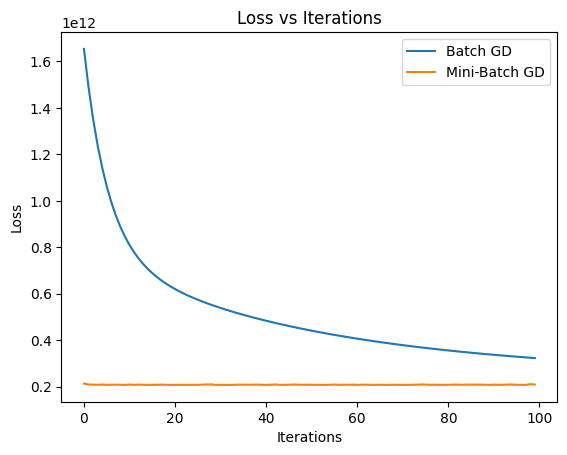

In [222]:
plt.figure()
plt.plot(loss_batch, label="Batch GD")
plt.plot(loss_mini, label="Mini-Batch GD")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")
plt.legend()
plt.show()

# Linear Regression 

#### Gradient Descent

In [223]:
class LinearRegressionGD:
    def __init__(self, eta=0.01, epoch=1000):
        self.eta = eta
        self.epoch = epoch
        self.w = None
        self.b = None

    def fit(self, X_train, y_train):
        m, n = X_train.shape

        self.w = np.zeros(n)
        self.b = 0

        for i in range(self.epoch):
            y_pred = X_train @ self.w + self.b
            error = y_pred - y_train

            dw = (2/m) * (X_train.T @ error)
            db = (2/m) * np.sum(error)

            self.w -= self.eta * dw
            self.b -= self.eta * db

In [224]:
lgd = LinearRegressionGD()
lgd.fit(X_train,y_train)

print(lgd.w)
print(lgd.b)


[ 5.74372647e+05  2.00383406e+04  2.80264962e+04  3.49376054e+04
  3.46488689e+04  5.92201415e+04  6.26574346e+04  6.32425633e+04
  6.47719196e+04  6.00551293e+04  5.50375110e+04  5.92244005e+04
  4.95938672e+04  4.15283065e+04  4.51052145e+04  4.22743243e+04
  5.57247980e+04  5.14159966e+04  5.49404695e+04  6.09942317e+04
  4.95496858e+04  5.44360747e+04  6.38664785e+04  6.20732863e+04
  6.77410842e+04 -1.28388255e+03  6.45452540e+05 -1.63955368e+04
 -2.59069915e+03  2.62592157e+03 -1.19602849e+03  7.47707096e+05
  3.81719262e+03  5.66183636e+03 -5.69201288e+03 -2.79668118e+02
 -3.54503903e+03  2.00396275e+04 -9.35820202e+03  1.02591415e+04
  8.45395681e+03  1.34984980e+04]
574372.6466190626


#### Normal Equation

In [225]:
class LinearRegression:
    def __init__(self):
        self.w = None
        self.b = None

    def fit(self,X_train,y_train):
        m = X_train.shape[0]

        X=np.hstack((np.ones((m,1)),X_train))

        theta = np.linalg.inv(X.T @ X) @ X.T @ y_train
        self.b = theta[0]
        self.w = theta[1:]
    
    def predict(self, X):
        y_pred = X @ self.w + self.b
    

In [226]:
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
print(lr.b)
print(lr.w)

-6.707624987286155e+24
[ 6.70762499e+24 -2.26500200e+09 -5.96864648e+08 -1.10805625e+09
 -5.45003199e+08 -3.00315984e+06 -4.53489534e+05 -1.10308609e+07
  8.22896213e+06 -7.35066651e+06 -8.36584930e+06 -4.10828460e+06
 -8.92545896e+06  3.06623340e+06 -1.05511218e+06 -7.12528686e+06
 -6.46275063e+08 -1.31465640e+09 -6.59554442e+08  2.94939453e+06
 -2.41301680e+06  2.72178201e+06 -2.03898763e+06 -1.04939874e+05
 -9.56315464e+06 -2.24989080e+06  1.86293113e+06  6.03000608e+06
  7.13694808e+05 -7.50227089e+06 -4.76540634e+05 -3.81183993e+06
 -4.81567567e+05  5.54212841e+05 -1.86709020e+06 -2.19046348e+04
 -2.65710613e+04 -3.36901060e+05 -6.03714181e+05  6.47004180e+04
  1.05819585e+05  2.24605007e+05]


# RIDGE

In [227]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
ridge=Ridge(alpha=1)
ridge.fit(X_train,y_train)
y_pred1 = ridge.predict(X_test)
print(r2_score(y_test,y_pred1))


0.7042894653053323


# Bagging Technique 
Random Forest

In [228]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train,y_train)
y_pred2 = rf.predict(X_test)
print(r2_score(y_test,y_pred2))

0.8225998133365953


# Kmeans Clustering

In [236]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_train)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

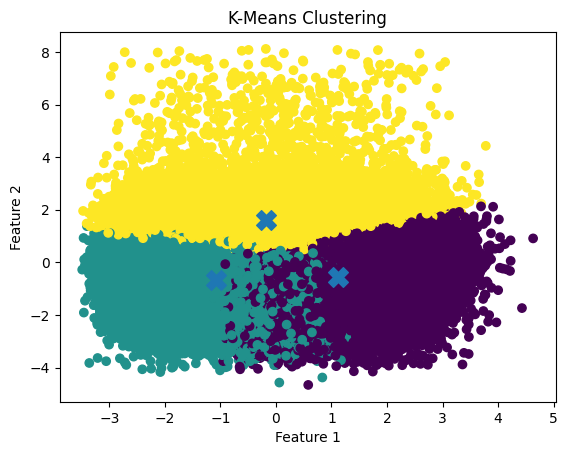

In [238]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

if X_train.shape[1] > 2:
    pca = PCA(n_components=2)
    X_vis = pca.fit_transform(X_train)
    centroids_vis = pca.transform(centroids)
else:
    X_vis = X_train
    centroids_vis = centroids

plt.scatter(X_vis[:, 0], X_vis[:, 1], c=labels)
plt.scatter(centroids_vis[:, 0], centroids_vis[:, 1], marker='X', s=200)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()